In [33]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.stats import mannwhitneyu
from sklearn.manifold import TSNE
import seaborn as sns 

sns.set_style("whitegrid")

QF_ROOT = Path("/n/netscratch/barak_lab/Everyone/sqin/variation/qf/hier90_linear10")
DATA_DIR = Path("/n/home07/vrli/id-predict-ood/question_formation_data/question_formation")
OUT_DIR = Path("/n/home07/vrli/id-predict-ood/question_formation_data/")

CHECKPOINT = 300000
GPU_ID = 0
device = torch.device(f"cuda:{GPU_ID}" if torch.cuda.is_available() else "cpu")

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"]
plt.rcParams["figure.dpi"] = 300

print("device:", device)

device: cuda:0


### Load Models

In [34]:
# ---------------------------------------------------------------------
# Repo imports, vocab, run discovery
# ---------------------------------------------------------------------
HIER_GEN_ROOT = Path("/n/home07/vrli/hier_gen")
sys.path.insert(0, str(HIER_GEN_ROOT))
# hier_gen's lm_dataset_helpers opens "cfgs/tag_token_map.txt" as a relative
# path at import time, so we must be in the hier_gen dir when importing.
os.chdir(HIER_GEN_ROOT)

from train_transformers import AttrDict, get_base_transformer_lm
from data_utils.lm_dataset_helpers import build_datasets_lm, read_lm_data

# Files live directly in DATA_DIR (question.{train,val,test}), and the loader
# resolves paths as {data_dir}/{data_name}/{filename}.{split}, so we pass the
# parent as data_dir and the folder name as data_name.
_, vocab, _ = build_datasets_lm(
    data_name=DATA_DIR.name,
    filename_prefix="question",
    test_filename_prefix="question",
    data_dir=str(DATA_DIR.parent),
    splits=["train", "val", "test"],
)

def load_args(run_dir):
    return AttrDict(json.load(open(Path(run_dir) / "args.json")))

def discover_runs():
    # Dedup by random seed
    rows = []
    seen_seeds = set()
    for run_dir in sorted(QF_ROOT.iterdir()):
        ckpt = run_dir / f"checkpoint_{CHECKPOINT}.pth"
        args_path = run_dir / "args.json"
        if run_dir.is_dir() and ckpt.exists() and args_path.exists():
            seed = load_args(run_dir).seed
            if seed in seen_seeds:
                continue
            seen_seeds.add(seed)
            rows.append({
                "run_dir": run_dir.name,
                "run_path": str(run_dir),
                "checkpoint_path": str(ckpt),
                "model_checkpoint": f"{run_dir.name}__checkpoint_{CHECKPOINT}",
            })
    return pd.DataFrame(rows)

runs_df = discover_runs()
model_cols = runs_df["model_checkpoint"].tolist()

print("models:", len(model_cols))
runs_df

num examples: 111000


models: 79


,run_dir,run_path,checkpoint_path,model_checkpoint
0,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...
1,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...
2,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...
3,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...
4,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...
...,...,...,...,...
74,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...
75,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...
76,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...
77,question_D_hier90_linear10_two_phase_200k_seed...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,/n/netscratch/barak_lab/Everyone/sqin/variatio...,question_D_hier90_linear10_two_phase_200k_seed...


### Load Data

In [35]:
# ---------------------------------------------------------------------
# QF parsing — locate matrix_aux, first_aux, and quest positions.
# Assumes every question prefix is <content> "." "quest" with >=1 aux
# and that each aux/rel is a single vocab token (verified on val + test).
# ---------------------------------------------------------------------

# The task is to turn a statement into a yes/no question by moving one word (`do`, `does`, `don't`, or `doesn't`) to the front.

# **Example.** For the statement
# my newt who doesn't read does amuse my vulture .
# the correct question is
# does my newt who doesn't read amuse my vulture ?

from data_utils.lm_dataset_helpers import type_to_token_map

AUXS = set(type_to_token_map["aux_s"]) | set(type_to_token_map["aux_p"])
RELS = set(type_to_token_map["rel"])

def parse_qf_example(sent):
    """SOS-shifted positions of matrix aux, first aux, and 'quest'."""
    prefix = sent.split(" quest ", 1)[0] + " quest"
    words = prefix.split()

    aux_idxs = [i for i, w in enumerate(words) if w in AUXS]
    rel_idxs = [i for i, w in enumerate(words) if w in RELS]

    first_aux_i = aux_idxs[0]
    if rel_idxs:
        auxes_before_rel = [i for i in aux_idxs if i < rel_idxs[0]]
        # object RC → matrix aux precedes the rel; subject RC → matrix aux is the last aux.
        matrix_aux_i = auxes_before_rel[0] if auxes_before_rel else aux_idxs[-1]
    else:
        matrix_aux_i = first_aux_i

    # +1 shift for the SOS token prepended at model input time.
    return dict(
        prefix=prefix,
        words=["<s>"] + words,
        quest_i=len(words),                       # 'quest' is the last word of prefix
        matrix_aux_i=matrix_aux_i + 1,
        first_aux_i=first_aux_i + 1,
        matrix_aux_word=words[matrix_aux_i],
        first_aux_word=words[first_aux_i],
    )

def load_qf_split_meta(split):
    sents, _ = read_lm_data(
        [split],
        data_name=DATA_DIR.name,
        filename_prefix="question",
        data_dir=str(DATA_DIR.parent),
    )
    # exclude 'decl' examples
    return pd.DataFrame(parse_qf_example(s) for s in sents if " quest " in s)

id_meta = load_qf_split_meta("val")
ood_meta = load_qf_split_meta("test")

# OOD by construction contains only examples where the hierarchical (matrix)
# and linear (first) rules disagree — that's what makes them discriminating.
# Assert so a future data change with mixed structures fails loudly.
assert (ood_meta["matrix_aux_word"] != ood_meta["first_aux_word"]).all(), \
    "OOD split should contain only examples where hier and linear rules disagree"
ood_meta = ood_meta.rename(columns={
    "matrix_aux_word": "hier_aux_word",
    "first_aux_word": "linear_aux_word",
})
ood_meta["hier_aux_id"] = ood_meta["hier_aux_word"].apply(lambda w: vocab(w)[0])
ood_meta["linear_aux_id"] = ood_meta["linear_aux_word"].apply(lambda w: vocab(w)[0])

print("ID examples:", len(id_meta))
print("OOD examples:", len(ood_meta))
display(id_meta[["prefix", "matrix_aux_word", "first_aux_word"]].head())
display(ood_meta[["prefix", "hier_aux_word", "linear_aux_word"]].head())

ID examples: 406
OOD examples: 10000


,prefix,matrix_aux_word,first_aux_word
0,our tyrannosaurus doesn't comfort my yaks who ...,doesn't,doesn't
1,our orangutan behind your vultures does entert...,does,does
2,her peacock does amuse our xylophone that some...,does,does
3,the quail doesn't entertain our xylophone . quest,doesn't,doesn't
4,my tyrannosaurus doesn't high_five some walrus...,doesn't,doesn't


,prefix,hier_aux_word,linear_aux_word
0,the peacocks who do comfort her xylophone don'...,don't,do
1,her orangutan who doesn't admire our quail doe...,does,doesn't
2,my raven that doesn't sleep does change . quest,does,doesn't
3,my newt who doesn't read does amuse my vulture...,does,doesn't
4,your yaks who do entertain my tyrannosaurus do...,don't,do


In [36]:
parse_qf_example("your yaks who do entertain my tyrannosaurus do want")

{'prefix': 'your yaks who do entertain my tyrannosaurus do want quest',
 'words': ['<s>',
  'your',
  'yaks',
  'who',
  'do',
  'entertain',
  'my',
  'tyrannosaurus',
  'do',
  'want',
  'quest'],
 'quest_i': 10,
 'matrix_aux_i': 8,
 'first_aux_i': 4,
 'matrix_aux_word': 'do',
 'first_aux_word': 'do'}

### Get OOD Accuracy

In [37]:
# ---------------------------------------------------------------------
# Model loading, attention capture, ablation, and OOD scoring utilities
# ---------------------------------------------------------------------
# The model always returns a TransformerResult with logits at key "data"
# ([B, seq, V]) and only calls F.softmax inside attention — no torch.softmax
# or tensor-method form, so patching F.softmax alone catches all attention.
# TransformerLM exposes its SOS id as `model.encoder_sos`.

def load_model_for_col(model_col):
    run_name = model_col.replace(f"__checkpoint_{CHECKPOINT}", "")
    run_dir = QF_ROOT / run_name
    args = load_args(run_dir)
    model, _ = get_base_transformer_lm(args, vocab, model_name=str(run_dir / f"checkpoint_{CHECKPOINT}.pth"))
    model.to(device).eval()
    return model, args, run_name

class AttentionCaptureOrAblator:
    """Captures per-layer attention tensors and optionally ablates selected heads."""
    def __init__(self, B, n_layers, n_heads, seq, ablate_heads=None, mode=None, mean_attn=None):
        self.B, self.n_layers, self.n_heads, self.seq = int(B), int(n_layers), int(n_heads), int(seq)
        self.ablate_heads = set() if ablate_heads is None else {(int(l), int(h)) for l, h in ablate_heads}
        self.mode = mode
        self.mean_attn = mean_attn or {}
        self.attn_call_idx = 0
        self.captured = []

    def _process_attention(self, a):
        # a: [B, n_heads, seq, seq] from F.softmax inside multi_head_attention.
        if not (torch.is_tensor(a) and a.ndim == 4 and a.shape[:2] == (self.B, self.n_heads) and a.shape[-1] == self.seq):
            return a

        layer = self.attn_call_idx
        self.attn_call_idx += 1
        if layer >= self.n_layers:
            return a

        self.captured.append(a.detach().cpu())

        selected = [h for l, h in self.ablate_heads if l == layer and 0 <= h < self.n_heads]
        if not selected or self.mode is None:
            return a

        a = a.clone()
        if self.mode == "uniform":
            sel = torch.tensor(selected, dtype=torch.long, device=a.device)
            support = a[:, sel, :, :] > 0
            denom = support.sum(dim=-1, keepdim=True).clamp(min=1)
            a[:, sel, :, :] = support.to(dtype=a.dtype) / denom.to(dtype=a.dtype)
        elif self.mode == "mean":
            for h in selected:
                repl = self.mean_attn.get((int(layer), int(h)))
                if repl is not None:
                    a[:, h, :, :] = repl.to(device=a.device, dtype=a.dtype)[None, :, :]
        else:
            raise ValueError("mode must be None, 'uniform', or 'mean'")

        return a

    def __enter__(self):
        self._orig = F.softmax
        def patched(x, *args, **kwargs):
            return self._process_attention(self._orig(x, *args, **kwargs))
        F.softmax = patched
        return self

    def __exit__(self, *args):
        F.softmax = self._orig

def forward_next_logits(model, vocab, args, prefixes, device, fixed_seq=None, ablate_heads=None, mode=None, mean_attn=None, return_capture=False):
    seqs = [[model.encoder_sos] + vocab(p) for p in prefixes]
    B = len(seqs)
    seq = max(len(s) for s in seqs) if fixed_seq is None else int(fixed_seq)

    x = torch.zeros(B, seq, dtype=torch.long, device=device)
    lens = torch.tensor([len(s) for s in seqs], dtype=torch.long, device=device)
    for i, s in enumerate(seqs):
        x[i, :len(s)] = torch.tensor(s, dtype=torch.long, device=device)

    ctx = AttentionCaptureOrAblator(B, args.encoder_n_layers, args.n_heads, seq, ablate_heads, mode, mean_attn)
    with ctx, torch.no_grad():
        out = model(x, lens, prefix_len=lens) if args.is_prefix_lm else model(x, lens)

    logits = out["data"]                                        # [B, seq, V]
    pos = torch.clamp(lens - 1, max=logits.shape[1] - 1)
    next_logits = logits[torch.arange(B, device=device), pos]   # [B, V]

    return (next_logits, ctx.captured) if return_capture else next_logits

BATCH_SIZE = 8 

def score_ood_p_hier_vector(model, vocab, args, ood_meta, device, ablate_heads=None, mode=None, mean_attn=None, fixed_seq=None, batch_size=BATCH_SIZE):
    vals = []
    for st in range(0, len(ood_meta), batch_size):
        mb = ood_meta.iloc[st:st + batch_size].reset_index(drop=True)
        logits = forward_next_logits(
            model=model, vocab=vocab, args=args,
            prefixes=mb["prefix"].tolist(), device=device,
            fixed_seq=fixed_seq, ablate_heads=ablate_heads, mode=mode, mean_attn=mean_attn,
        )
        probs = torch.softmax(logits, dim=-1)
        h_ids = torch.tensor(mb["hier_aux_id"].to_numpy(), dtype=torch.long, device=device)
        l_ids = torch.tensor(mb["linear_aux_id"].to_numpy(), dtype=torch.long, device=device)
        idx = torch.arange(len(mb), device=device)
        p_h = probs[idx, h_ids]
        p_l = probs[idx, l_ids]
        vals.append(p_h.detach().cpu().numpy())  # OOD metric: raw P(hier) = prob mass on the matrix (hierarchical) auxiliary
    return np.concatenate(vals)

In [38]:
# ---------------------------------------------------------------------
# Compute or load OOD P(hierarchical) vectors for t-SNE and OOD accuracy
# ---------------------------------------------------------------------

OUT_P_HIER = OUT_DIR / f"qf_p_hier_by_model_checkpoint_{CHECKPOINT}.csv"

if OUT_P_HIER.exists():
    p_hier_df = pd.read_csv(OUT_P_HIER)
    print("Loaded:", OUT_P_HIER)
else:
    p_hier_df = ood_meta[["prefix", "hier_aux_word", "linear_aux_word"]].copy()
    for model_col in tqdm(model_cols, desc="models"):
        model, args, run_name = load_model_for_col(model_col)
        p_hier_df[model_col] = score_ood_p_hier_vector(
            model=model, vocab=vocab, args=args,
            ood_meta=ood_meta, device=device, batch_size=BATCH_SIZE,
        )
        p_hier_df.to_csv(OUT_P_HIER, index=False)
        del model
        torch.cuda.empty_cache()
    print("Saved:", OUT_P_HIER)

model_cols = [c for c in model_cols if c in p_hier_df.columns]
print("models with OOD scores:", len(model_cols))
display(p_hier_df[model_cols].mean(axis=0).describe())

Loaded: /n/home07/vrli/id-predict-ood/question_formation_data/qf_p_hier_by_model_checkpoint_300000.csv
models with OOD scores: 79


count    79.000000
mean      0.613263
std       0.383215
min       0.000015
25%       0.243272
50%       0.752135
75%       0.962991
max       0.999984
dtype: float64

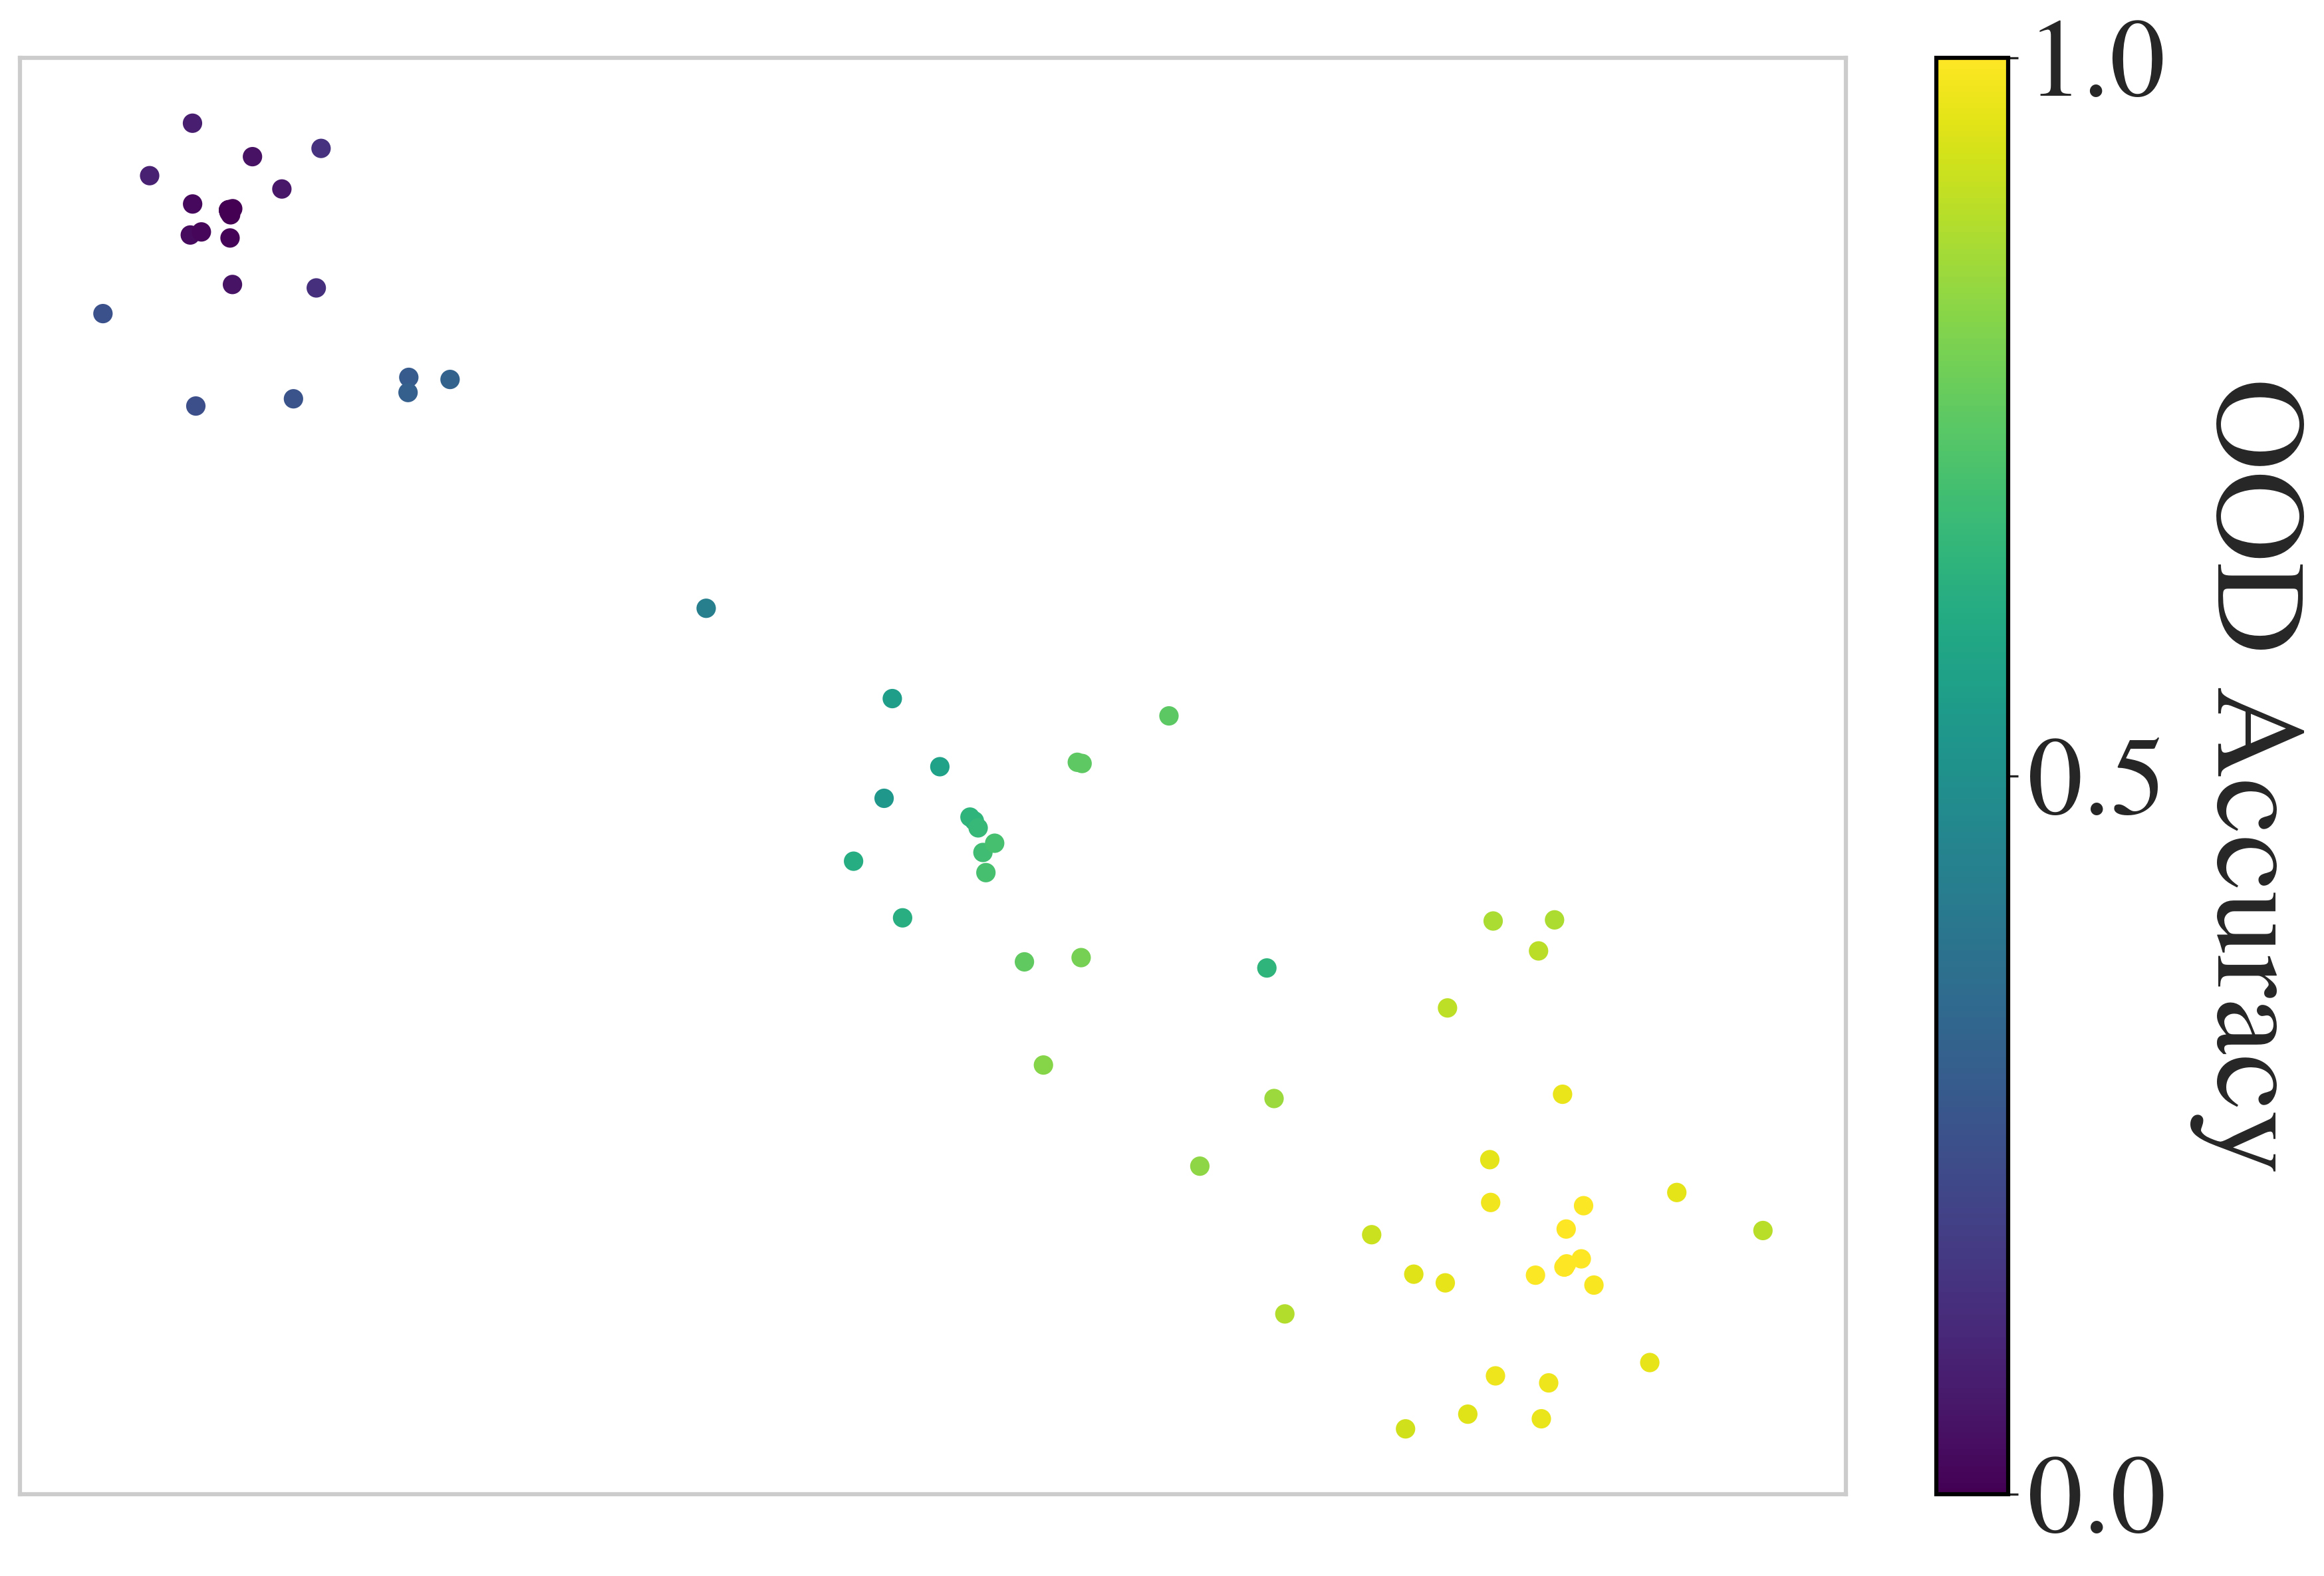

In [ ]:
# ---------------------------------------------------------------------
# Figure: OOD t-SNE  (mirrors preds_attention_heads.ipynb's get_tsne_plot)
# ---------------------------------------------------------------------

def plot_ood_tsne():
    X = p_hier_df[model_cols].T.to_numpy()
    ood_accuracy = X.mean(axis=1)

    xy = TSNE(
        n_components=2,
        random_state=56,
        perplexity=29
    ).fit_transform(X)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(xy[:, 0], xy[:, 1],
                          c=ood_accuracy, cmap="viridis",
                          vmin=0, vmax=1)
    colorbar = plt.colorbar(scatter, label="OOD Accuracy",
                            ticks=[0, 0.5, 1], pad=0.04)
    colorbar.ax.tick_params(labelsize=40)
    colorbar.ax.set_ylabel("OOD Accuracy", fontsize=46, rotation=270, labelpad=50)
    colorbar.outline.set_edgecolor("black")
    colorbar.outline.set_linewidth(1.5)

    # --- shared plot formatting (kept identical to plot_ood_tsne / get_tsne_plot) ---
    ax = plt.gca()
    ax.set_facecolor("white")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    plt.xticks([])
    plt.yticks([])

    plt.tight_layout()
    
    plt.show()

    return pd.DataFrame({
        "model_checkpoint": model_cols,
        "tsne_1": xy[:, 0],
        "tsne_2": xy[:, 1],
        "ood_accuracy": ood_accuracy,
    })

tsne_df = plot_ood_tsne()

In [40]:
PATTERN = "matrix_aux_detector_raw"
READOUT = "quest"
# Restrict detection to the first three layers. The attention capture below
# patches only F.softmax (one true tensor per layer, correctly labeled), so
# this is the honest first-three-layers rule -- not the double-counted layers
# an all-softmax patch would produce.
SCOPE = "first_three_layers"

HIGH_TOKEN_ATTN = 0.20
HEAD_PROP_THRESHOLD = 0.80
# ---------------------------------------------------------------------
# Extract quest-time matrix auxiliary retrieval heads from ID examples
# ---------------------------------------------------------------------
ATTN_BATCH_SIZE = 32

def get_batch_attns(model, vocab, prefixes, args, device):
    """Return per-layer attention tensors ([B, n_heads, seq, seq]) for a batch of prefixes."""
    _, captured = forward_next_logits(
        model=model, vocab=vocab, args=args,
        prefixes=prefixes, device=device, return_capture=True,
    )
    return captured

def score_matrix_aux_retrieval_heads(model, vocab, args, id_meta, device, batch_size=ATTN_BATCH_SIZE):
    L, H = int(args.encoder_n_layers), int(args.n_heads)
    sums = np.zeros((L, H), dtype=np.float64)
    mets = np.zeros((L, H), dtype=np.float64)
    cnts = np.zeros((L, H), dtype=np.float64)

    for st in range(0, len(id_meta), batch_size):
        mb = id_meta.iloc[st:st + batch_size].reset_index(drop=True)
        attns = get_batch_attns(model, vocab, mb["prefix"].tolist(), args, device)
        for layer, A in enumerate(attns):
            for b, r in mb.iterrows():
                vals = A[b, :, int(r["quest_i"]), int(r["matrix_aux_i"])].numpy()
                sums[layer, :] += vals
                mets[layer, :] += (vals >= HIGH_TOKEN_ATTN).astype(float)
                cnts[layer, :] += 1.0

    rows = []
    for layer in range(L):
        for head in range(H):
            n_valid = int(cnts[layer, head])
            rows.append({
                "layer": layer,
                "head": head,
                "readout": READOUT,
                "pattern": PATTERN,
                "n_valid": n_valid,
                "prop_met": float(mets[layer, head] / n_valid) if n_valid else np.nan,
                "mean_score": float(sums[layer, head] / n_valid) if n_valid else np.nan,
            })
    return pd.DataFrame(rows)

OUT_HEADS = OUT_DIR / f"qf_{PATTERN}_{READOUT}_heads_{CHECKPOINT}.csv"

if OUT_HEADS.exists():
    id_heads_df = pd.read_csv(OUT_HEADS)
    print("Loaded:", OUT_HEADS)
else:
    rows = []
    for model_col in tqdm(model_cols, desc="models"):
        model, args, run_name = load_model_for_col(model_col)
        hdf = score_matrix_aux_retrieval_heads(model, vocab, args, id_meta, device)
        hdf.insert(0, "model_checkpoint", model_col)
        hdf.insert(1, "run_dir", run_name)
        hdf.insert(2, "checkpoint", CHECKPOINT)
        hdf.insert(3, "ood_accuracy", float(p_hier_df[model_col].mean()))
        rows.append(hdf)
        pd.concat(rows, ignore_index=True).to_csv(OUT_HEADS, index=False)
        del model
        torch.cuda.empty_cache()

    id_heads_df = pd.concat(rows, ignore_index=True)
    print("Saved:", OUT_HEADS)

display(id_heads_df.head())

Loaded: /n/home07/vrli/id-predict-ood/question_formation_data/qf_matrix_aux_detector_raw_quest_heads_300000.csv


,model_checkpoint,run_dir,checkpoint,ood_accuracy,layer,head,readout,pattern,n_valid,prop_met,mean_score
0,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,300000,0.999951,0,0,quest,matrix_aux_detector_raw,406,0.000000,2.547090e-19
1,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,300000,0.999951,0,1,quest,matrix_aux_detector_raw,406,0.000000,3.198194e-22
2,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,300000,0.999951,0,2,quest,matrix_aux_detector_raw,406,0.000000,1.551692e-08
3,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,300000,0.999951,0,3,quest,matrix_aux_detector_raw,406,0.268473,2.437540e-01
4,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,300000,0.999951,0,4,quest,matrix_aux_detector_raw,406,0.815271,8.015124e-01


In [41]:
# ---------------------------------------------------------------------
# Membership and predictive summary
# ---------------------------------------------------------------------

def scope_mask_heads(sub, scope=SCOPE):
    max_layer = int(sub["layer"].max())
    if scope == "any_layer":
        return np.ones(len(sub), dtype=bool)
    if scope == "first_three_layers":
        return sub["layer"].to_numpy() <= 2
    if scope == "not_first_layer":
        return sub["layer"].to_numpy() > 0
    if scope == "final_two_layers":
        return sub["layer"].to_numpy() >= max_layer - 1
    if scope == "last_layer":
        return sub["layer"].to_numpy() == max_layer
    raise ValueError(scope)

def heads_for_matrix_aux_rule(model_col, scope=SCOPE, threshold=HEAD_PROP_THRESHOLD):
    sub = id_heads_df[
        (id_heads_df["model_checkpoint"] == model_col)
        & (id_heads_df["pattern"] == PATTERN)
        & (id_heads_df["readout"] == READOUT)
        & (id_heads_df["n_valid"] > 0)
    ]
    if len(sub) == 0:
        return tuple()
    sub = sub[scope_mask_heads(sub, scope) & (sub["prop_met"] >= threshold)]
    return tuple(sorted({(int(r.layer), int(r.head)) for r in sub.itertuples()}))

membership = []
for model_col in model_cols:
    heads = heads_for_matrix_aux_rule(model_col)
    membership.append({
        "model_checkpoint": model_col,
        "contains_matrix_aux_retrieval_head": len(heads) > 0,
        "matching_heads": str(heads),
        "n_matching_heads": len(heads),
        "ood_accuracy": float(p_hier_df[model_col].mean()),
    })

model_rule_df = pd.DataFrame(membership)
present = model_rule_df[model_rule_df["contains_matrix_aux_retrieval_head"]]
absent = model_rule_df[~model_rule_df["contains_matrix_aux_retrieval_head"]]

summary = pd.DataFrame([{
    "rule": f"{PATTERN}/{READOUT}/{SCOPE}/prop>={HEAD_PROP_THRESHOLD}",
    "n_present": len(present),
    "n_absent": len(absent),
    "mean_ood_present": present["ood_accuracy"].mean(),
    "mean_ood_absent": absent["ood_accuracy"].mean(),
    "delta_present_minus_absent": present["ood_accuracy"].mean() - absent["ood_accuracy"].mean(),
    "median_ood_present": present["ood_accuracy"].median(),
    "median_ood_absent": absent["ood_accuracy"].median(),
}])

if len(present) and len(absent):
    summary["mannwhitney_p"] = mannwhitneyu(present["ood_accuracy"], absent["ood_accuracy"], alternative="two-sided").pvalue

OUT_MEMBERSHIP = OUT_DIR / f"qf_{PATTERN}_{READOUT}_membership_{CHECKPOINT}.csv"
model_rule_df.to_csv(OUT_MEMBERSHIP, index=False)

display(summary)
display(model_rule_df.head())
print("Saved:", OUT_MEMBERSHIP)

,rule,n_present,n_absent,mean_ood_present,mean_ood_absent,delta_present_minus_absent,median_ood_present,median_ood_absent,mannwhitney_p
0,matrix_aux_detector_raw/quest/first_three_laye...,59,20,0.689521,0.388305,0.301216,0.849844,0.194098,0.013758


,model_checkpoint,contains_matrix_aux_retrieval_head,matching_heads,n_matching_heads,ood_accuracy
0,question_D_hier90_linear10_two_phase_200k_seed...,True,"((0, 4), (0, 7), (2, 3))",3,0.999951
1,question_D_hier90_linear10_two_phase_200k_seed...,False,(),0,0.257079
2,question_D_hier90_linear10_two_phase_200k_seed...,False,(),0,0.002516
3,question_D_hier90_linear10_two_phase_200k_seed...,True,"((2, 1),)",1,0.010333
4,question_D_hier90_linear10_two_phase_200k_seed...,True,"((1, 3), (1, 7), (2, 6))",3,0.045380


Saved: /n/home07/vrli/id-predict-ood/question_formation_data/qf_matrix_aux_detector_raw_quest_membership_300000.csv


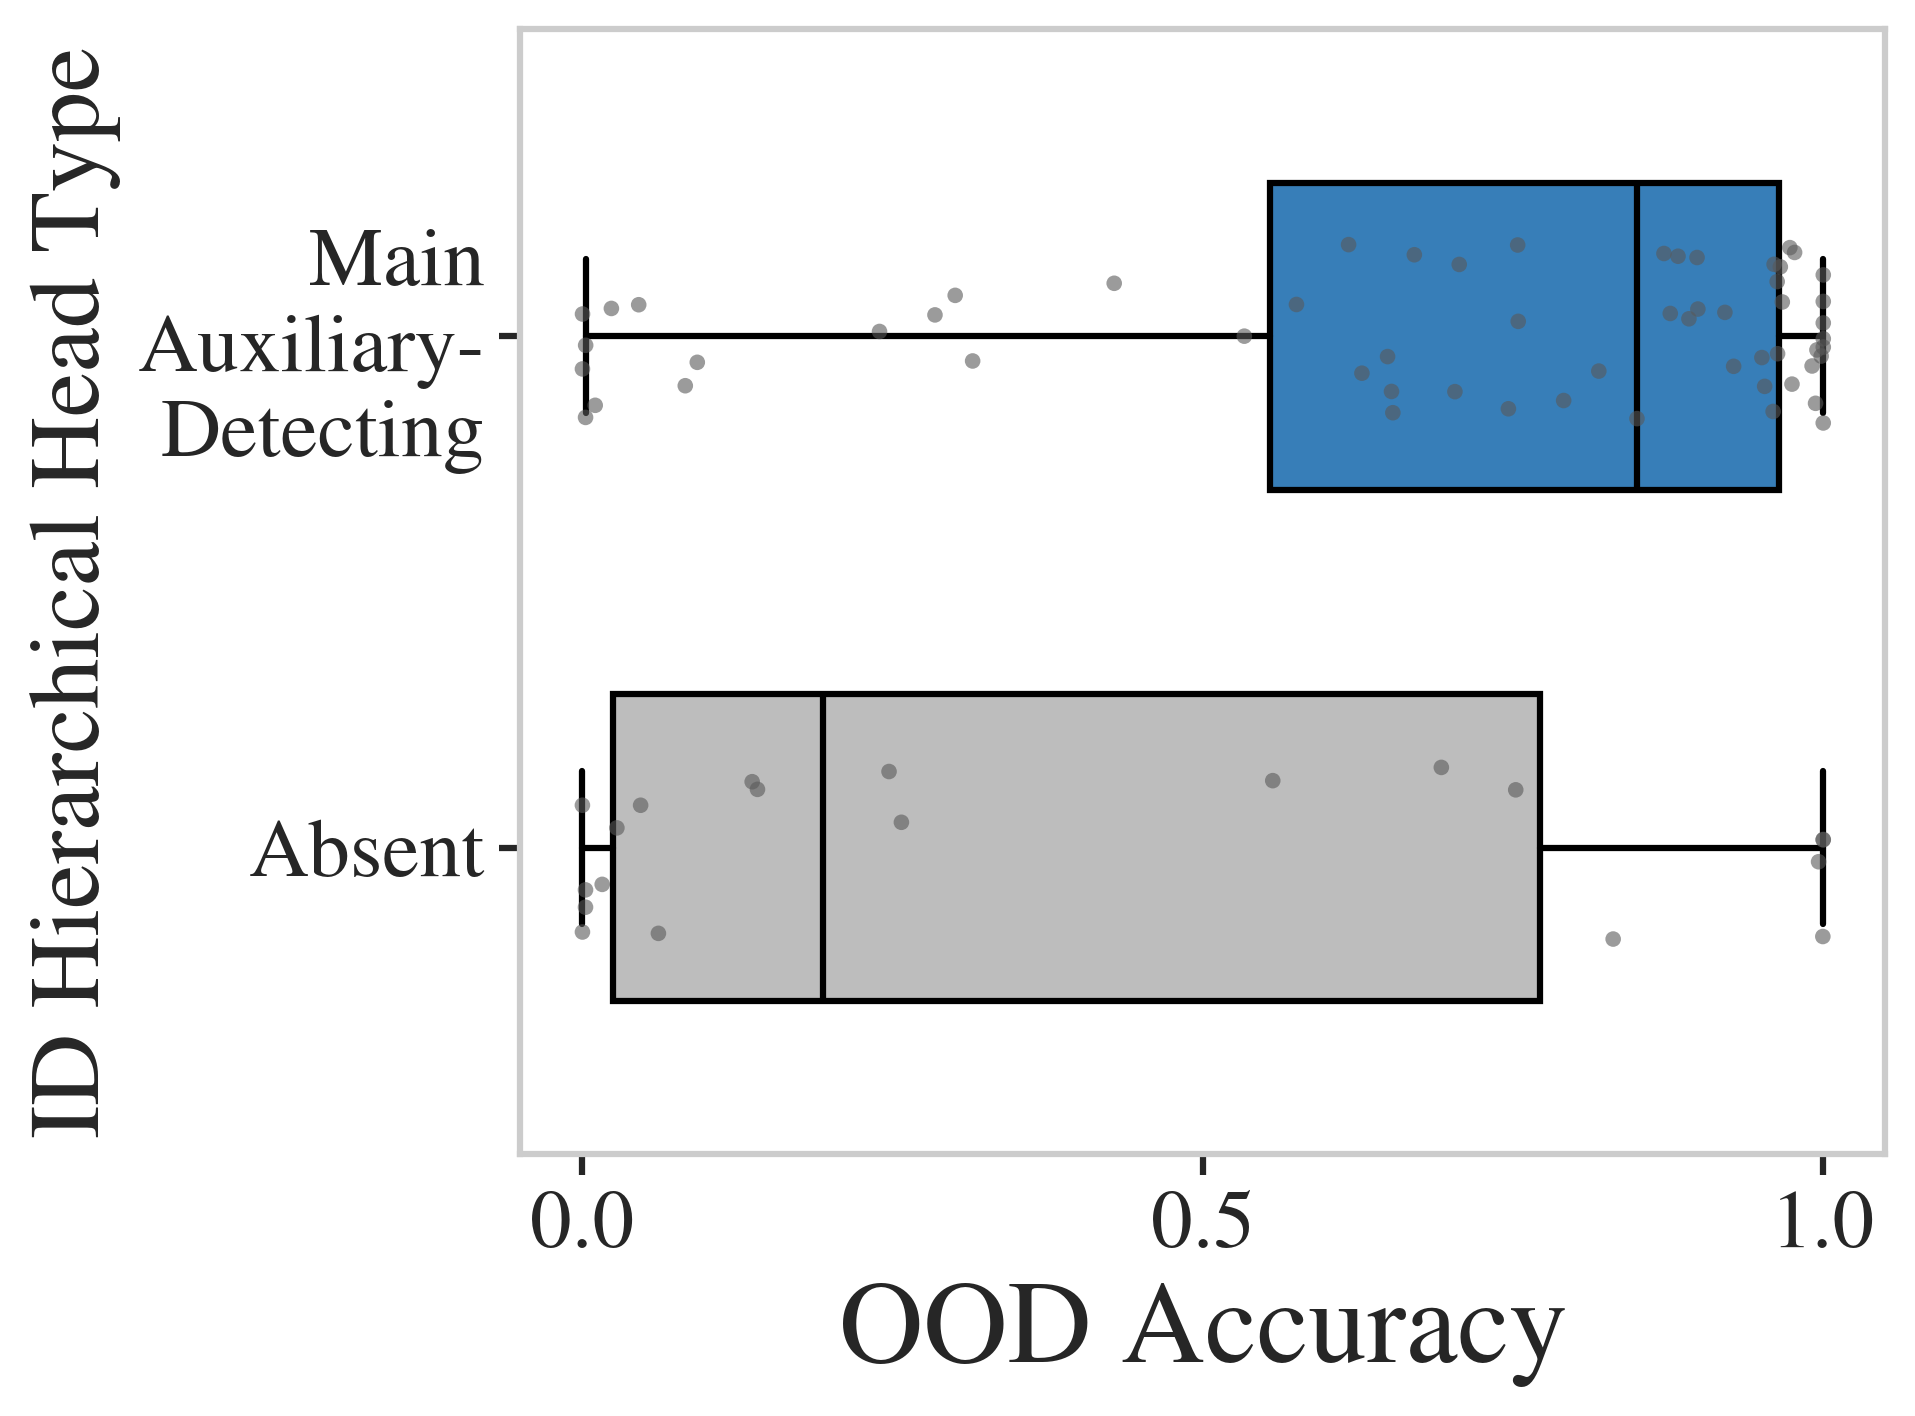

In [ ]:
# ---------------------------------------------------------------------
# Figure: Predictor boxplot
# ---------------------------------------------------------------------

def plot_matrix_aux_boxplot(out_prefix="fig_boxplot_quest_time_matrix_aux_retrieval_head", seed=0):
    other = model_rule_df.loc[~model_rule_df["contains_matrix_aux_retrieval_head"], "ood_accuracy"].to_numpy()
    contains = model_rule_df.loc[model_rule_df["contains_matrix_aux_retrieval_head"], "ood_accuracy"].to_numpy()

    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
    positions = np.array([1, 2])
    widths = 0.6

    bp = ax.boxplot(
        [other, contains],
        vert=False,
        positions=positions,
        widths=widths,
        patch_artist=True,
        whis=[5, 95],
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.5),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
    )
    for patch, color in zip(bp["boxes"], ["#bdbdbd", "#377eb8"]):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")

    rng = np.random.default_rng(seed)
    for pos, vals in zip(positions, [other, contains]):
        if len(vals) == 0:
            continue
        jitter = rng.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(vals, np.full(len(vals), pos) + jitter,
                   s=14, color="0.35", alpha=0.6, edgecolor="none", zorder=3)

    ax.set_yticks(positions)
    ax.set_yticklabels(["Absent", "Main\nAuxiliary-\nDetecting"], fontsize=20)
    ax.set_ylabel("ID Hierarchical Head Type", fontsize=24)
    ax.set_xlabel("OOD Accuracy", fontsize=28)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(positions.min() - 0.6, positions.max() + 0.6)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    ax.tick_params(axis="both", which="major", labelsize=20, width=1.5, length=5)
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    fig.subplots_adjust(left=0.32, right=0.97, top=0.95, bottom=0.20)
    
    return fig, ax

box_fig, box_ax = plot_matrix_aux_boxplot()

In [43]:
# ---------------------------------------------------------------------
# Qualitative examples for the first model/head containing the rule
# ---------------------------------------------------------------------

def top_tokens_from_attention(words, attn_vec, k=8):
    pairs = []
    for i, w in enumerate(words):
        if i < len(attn_vec):
            pairs.append((i, w, float(attn_vec[i])))
    return sorted(pairs, key=lambda x: x[2], reverse=True)[:k]

def show_qualitative_examples(n_examples=5):
    present_models = model_rule_df[model_rule_df["contains_matrix_aux_retrieval_head"]].copy()
    if len(present_models) == 0:
        print("No models contain the rule.")
        return pd.DataFrame()

    model_col = present_models.iloc[0]["model_checkpoint"]
    heads = heads_for_matrix_aux_rule(model_col)
    layer, head = heads[0]

    model, args, run_name = load_model_for_col(model_col)
    mb = id_meta.head(n_examples).reset_index(drop=True)
    attns = get_batch_attns(model, vocab, mb["prefix"].tolist(), args, device)
    A = attns[layer]

    rows = []
    for b, r in mb.iterrows():
        qi = int(r["quest_i"])
        mi = int(r["matrix_aux_i"])
        words = r["words"]
        attn_vec = A[b, head, qi, :].numpy()
        rows.append({
            "model_checkpoint": model_col,
            "head": (layer, head),
            "prefix": r["prefix"],
            "matrix_aux": words[mi],
            "attention_to_matrix_aux": float(attn_vec[mi]),
            "top_attended_tokens_from_quest": top_tokens_from_attention(words, attn_vec, k=8),
        })

    del model
    torch.cuda.empty_cache()
    return pd.DataFrame(rows)

qual_examples_df = show_qualitative_examples(n_examples=5)
display(qual_examples_df)

loading pretrained model from /n/netscratch/barak_lab/Everyone/sqin/variation/qf/hier90_linear10/question_D_hier90_linear10_two_phase_200k_seed100_13748191/checkpoint_300000.pth


/n/home07/vrli/hier_gen/train_transformers.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_state_dict = torch.load(model_name, map_location=torch.device("cpu"))

,model_checkpoint,head,prefix,matrix_aux,attention_to_matrix_aux,top_attended_tokens_from_quest
0,question_D_hier90_linear10_two_phase_200k_seed...,"(0, 4)",our tyrannosaurus doesn't comfort my yaks who ...,doesn't,0.999775,"[(3, doesn't, 0.999775230884552), (10, does, 0..."
1,question_D_hier90_linear10_two_phase_200k_seed...,"(0, 4)",our orangutan behind your vultures does entert...,does,1.000000,"[(6, does, 1.0), (3, behind, 5.014634269894652..."
2,question_D_hier90_linear10_two_phase_200k_seed...,"(0, 4)",her peacock does amuse our xylophone that some...,does,0.002950,"[(10, doesn't, 0.997050404548645), (3, does, 0..."
3,question_D_hier90_linear10_two_phase_200k_seed...,"(0, 4)",the quail doesn't entertain our xylophone . quest,doesn't,1.000000,"[(3, doesn't, 1.0), (4, entertain, 1.898851205..."
4,question_D_hier90_linear10_two_phase_200k_seed...,"(0, 4)",my tyrannosaurus doesn't high_five some walrus...,doesn't,0.973291,"[(3, doesn't, 0.9732913374900818), (8, don't, ..."


## Ablation experiments

We mirror the Dyck-1 targeted causal-ablation experiments in this question-formation setting, restricted to the
**head of interest**: the **matrix-auxiliary–detecting head** in the **first three layers**

We *only* ablate that head (never the whole model), in two scopes × two methods — 
four ablation *types*:

| scope | method | meaning |
|---|---|---|
| all together | uniform | overwrite **all** of a model's matrix-aux heads at once with a uniform distribution over their support |
| all together | mean | overwrite them at once with their mean attention pattern |
| one at a time | uniform | uniform-ablate **each** matrix-aux head individually; impact averaged over the model's heads |
| one at a time | mean | mean-ablate each individually; impact averaged over the model's heads |

Per model we record, before and after each ablation,

- **OOD accuracy** = mean `P(hier)` on a fixed 1 000-example OOD subsample (same metric as
  the t-SNE / boxplot above), and
- **ID accuracy** = fraction of ID-val examples whose greedy next token is the correct
  matrix auxiliary,

and report the **distribution of the impact (after − before)** over the population, split by
whether the model **contains** the matrix-aux head, **with 95% confidence intervals / margin
of error** on the mean impact.

In [44]:
# ---------------------------------------------------------------------
# Targeted ablation sweep: uniform / mean ablation of the matrix-aux
# head(s), (a) all together and (b) one at a time, per model. OOD + ID
# impact. Mirrors Dyck-1 §4.3 / Fig. 5 / Appx. L single-head ablations.
# Reuses AttentionCaptureOrAblator unchanged.
# ---------------------------------------------------------------------
ABL_N_OOD = 1000          # OOD subsample size (Dyck used a 1K OOD set)
ABL_BATCH = 32
ABL_SEED = 0

# The correct next token on an ID example is its matrix auxiliary; needed for ID accuracy.
if "matrix_aux_id" not in id_meta.columns:
    id_meta["matrix_aux_id"] = id_meta["matrix_aux_word"].apply(lambda w: vocab(w)[0])

def score_id_acc_vector(model, vocab, args, meta, device, ablate_heads=None, mode=None,
                        mean_attn=None, fixed_seq=None, batch_size=ABL_BATCH):
    """Per-example greedy correctness: argmax next token == matrix auxiliary id."""
    vals = []
    for st in range(0, len(meta), batch_size):
        mb = meta.iloc[st:st + batch_size].reset_index(drop=True)
        logits = forward_next_logits(model, vocab, args, mb["prefix"].tolist(), device,
                                     fixed_seq=fixed_seq, ablate_heads=ablate_heads,
                                     mode=mode, mean_attn=mean_attn)
        pred = logits.argmax(dim=-1).detach().cpu().numpy()
        vals.append((pred == mb["matrix_aux_id"].to_numpy()).astype(float))
    return np.concatenate(vals)

def compute_mean_attn(model, vocab, args, meta, device, fixed_seq, batch_size=ABL_BATCH):
    """Per-(layer, head) mean attention map [fixed_seq, fixed_seq] over `meta`,
    used as the replacement pattern for mode='mean' ablation."""
    L, H = int(args.encoder_n_layers), int(args.n_heads)
    acc = [np.zeros((H, fixed_seq, fixed_seq), dtype=np.float64) for _ in range(L)]
    n = 0
    for st in range(0, len(meta), batch_size):
        mb = meta.iloc[st:st + batch_size].reset_index(drop=True)
        _, captured = forward_next_logits(model, vocab, args, mb["prefix"].tolist(), device,
                                          fixed_seq=fixed_seq, return_capture=True)
        for l, A in enumerate(captured):
            acc[l] += A.sum(dim=0).numpy()
        n += len(mb)
    return {(l, h): torch.tensor(acc[l][h] / max(n, 1), dtype=torch.float32)
            for l in range(L) for h in range(H)}

def _max_seq(meta):
    return int(meta["prefix"].apply(lambda p: len(vocab(p)) + 1).max())

OUT_ABL = OUT_DIR / f"qf_ablation_impact_{CHECKPOINT}.csv"            # model-level, all-together
OUT_ABL_SINGLE = OUT_DIR / f"qf_ablation_single_head_{CHECKPOINT}.csv"  # per (model, head)

if OUT_ABL.exists() and OUT_ABL_SINGLE.exists():
    ablation_df = pd.read_csv(OUT_ABL)
    single_head_df = pd.read_csv(OUT_ABL_SINGLE)
    print("Loaded:", OUT_ABL, "and", OUT_ABL_SINGLE)
else:
    rng = np.random.default_rng(ABL_SEED)
    ood_sub = ood_meta.iloc[np.sort(rng.choice(len(ood_meta), ABL_N_OOD, replace=False))].reset_index(drop=True)
    id_sub = id_meta.reset_index(drop=True)            # ID-val is small; use all of it
    FS_ood, FS_id = _max_seq(ood_sub), _max_seq(id_sub)

    rows, srows = [], []
    for model_col in tqdm(model_cols, desc="targeted ablation"):
        model, args, run_name = load_model_for_col(model_col)
        L, H = int(args.encoder_n_layers), int(args.n_heads)
        tgt = list(heads_for_matrix_aux_rule(model_col))

        ma_ood = compute_mean_attn(model, vocab, args, ood_sub, device, FS_ood)
        ma_id  = compute_mean_attn(model, vocab, args, id_sub,  device, FS_id)

        def ood(ah, mode, ma=None, fs=None):
            return float(score_ood_p_hier_vector(model, vocab, args, ood_sub, device,
                         ablate_heads=ah, mode=mode, mean_attn=ma, fixed_seq=fs,
                         batch_size=ABL_BATCH).mean())
        def idacc(ah, mode, ma=None, fs=None):
            return float(score_id_acc_vector(model, vocab, args, id_sub, device,
                         ablate_heads=ah, mode=mode, mean_attn=ma, fixed_seq=fs,
                         batch_size=ABL_BATCH).mean())

        ood_base, id_base = ood([], None), idacc([], None)
        rows.append(dict(
            model_checkpoint=model_col, run=run_name,
            contains=bool(len(tgt) > 0), n_target_heads=len(tgt), n_layers=L, n_heads=H,
            ood_base=ood_base, id_base=id_base,
            ood_uniform_alltogether=(ood(tgt, "uniform") if tgt else ood_base),
            ood_mean_alltogether=(ood(tgt, "mean", ma_ood, FS_ood) if tgt else ood_base),
            id_uniform_alltogether=(idacc(tgt, "uniform") if tgt else id_base),
            id_mean_alltogether=(idacc(tgt, "mean", ma_id, FS_id) if tgt else id_base),
        ))
        for (l, h) in tgt:                              # one-at-a-time
            srows.append(dict(
                model_checkpoint=model_col, contains=True, layer=l, head=h,
                ood_base=ood_base, id_base=id_base,
                ood_uniform=ood([(l, h)], "uniform"),
                ood_mean=ood([(l, h)], "mean", ma_ood, FS_ood),
                id_uniform=idacc([(l, h)], "uniform"),
                id_mean=idacc([(l, h)], "mean", ma_id, FS_id),
            ))
        pd.DataFrame(rows).to_csv(OUT_ABL, index=False)
        pd.DataFrame(srows).to_csv(OUT_ABL_SINGLE, index=False)
        del model
        torch.cuda.empty_cache()
    ablation_df = pd.DataFrame(rows)
    single_head_df = pd.DataFrame(srows)
    print("Saved:", OUT_ABL, "and", OUT_ABL_SINGLE)

print("models:", len(ablation_df),
      "| contains:", int(ablation_df["contains"].sum()),
      "| absent:", int((~ablation_df["contains"]).sum()),
      "| individual matrix-aux heads:", len(single_head_df))
display(ablation_df.head())

Loaded: /n/home07/vrli/id-predict-ood/question_formation_data/qf_ablation_impact_300000.csv and /n/home07/vrli/id-predict-ood/question_formation_data/qf_ablation_single_head_300000.csv
models: 79 | contains: 59 | absent: 20 | individual matrix-aux heads: 113


,model_checkpoint,run,contains,n_target_heads,n_layers,n_heads,ood_base,id_base,ood_uniform_alltogether,ood_mean_alltogether,id_uniform_alltogether,id_mean_alltogether
0,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,True,3,6,8,0.999842,1.0,0.998828,0.998934,1.0,1.0
1,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,False,0,6,8,0.262904,1.0,0.262904,0.262904,1.0,1.0
2,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,False,0,6,8,0.002310,1.0,0.002310,0.002310,1.0,1.0
3,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,True,1,6,8,0.005161,1.0,0.006022,0.005650,1.0,1.0
4,question_D_hier90_linear10_two_phase_200k_seed...,question_D_hier90_linear10_two_phase_200k_seed...,True,3,6,8,0.043730,1.0,0.040369,0.060576,1.0,1.0


In [45]:
# ---------------------------------------------------------------------
# Distribution of TARGETED ablation impact on the matrix-aux head,
# split by whether the model contains the head, with 95% CIs / margin
# of error on the mean impact. Impact = (metric after) - (before).
# No plot -- table only.
# ---------------------------------------------------------------------
EPS = 0.02          # |delta| below this counts as "no meaningful effect"
N_BOOT = 10000      # bootstrap resamples for the CI on the mean
CI_SEED = 0

# --- per-model deltas -------------------------------------------------
base = ablation_df.set_index("model_checkpoint")
# one-at-a-time: average each head's impact within a model.
s = single_head_df.copy()
for m in ["uniform", "mean"]:
    s[f"d_ood_{m}"] = s[f"ood_{m}"] - s["ood_base"]
    s[f"d_id_{m}"]  = s[f"id_{m}"]  - s["id_base"]
single_agg = s.groupby("model_checkpoint")[["d_ood_uniform", "d_ood_mean",
                                            "d_id_uniform", "d_id_mean"]].mean()

def model_deltas(scope, method):
    """Return (before, d_ood, d_id) arrays aligned over all models."""
    if scope == "all together":
        d_ood = (base[f"ood_{method}_alltogether"] - base["ood_base"])
        d_id  = (base[f"id_{method}_alltogether"]  - base["id_base"])
    else:  # one at a time -- absent models have no head -> 0 impact
        d_ood = single_agg[f"d_ood_{method}"].reindex(base.index).fillna(0.0)
        d_id  = single_agg[f"d_id_{method}"].reindex(base.index).fillna(0.0)
    return base["ood_base"], d_ood, d_id

# --- CI / margin-of-error helpers ------------------------------------
def boot_ci(d, n_boot=N_BOOT, seed=CI_SEED):
    d = np.asarray(d, float)
    if len(d) == 0:
        return (np.nan, np.nan)
    if np.allclose(d, d[0]):
        return (float(d[0]), float(d[0]))
    rng = np.random.default_rng(seed)
    means = d[rng.integers(0, len(d), size=(n_boot, len(d)))].mean(axis=1)
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))

def moe95(d):
    d = np.asarray(d, float)
    if len(d) < 2:
        return 0.0
    return float(1.96 * d.std(ddof=1) / np.sqrt(len(d)))   # normal-approx margin of error

ABLATIONS = [
    ("uniform", "all together",  "Uniform · all together"),
    ("mean",    "all together",  "Mean · all together"),
    ("uniform", "one at a time", "Uniform · one at a time"),
    ("mean",    "one at a time", "Mean · one at a time"),
]
GROUPS = [(True, "contains head"), (False, "absent")]

recs = []
for method, scope, label in ABLATIONS:
    before_all, dood_all, did_all = model_deltas(scope, method)
    for flag, gname in GROUPS:
        mask = (base["contains"] == flag).to_numpy()
        before = before_all.to_numpy()[mask]
        dood = dood_all.to_numpy()[mask]
        did  = did_all.to_numpy()[mask]
        lo, hi = boot_ci(dood)
        recs.append({
            "ablation": label, "population": gname, "n": int(mask.sum()),
            "mean_OOD_before": before.mean() if len(before) else np.nan,
            "mean_OOD_after": (before + dood).mean() if len(before) else np.nan,
            "mean_dOOD": dood.mean() if len(dood) else np.nan,
            "moe95_dOOD": moe95(dood),
            "ci95_dOOD": f"[{lo:+.3f}, {hi:+.3f}]",
            "median_dOOD": np.median(dood) if len(dood) else np.nan,
            "std_dOOD": dood.std(ddof=1) if len(dood) > 1 else 0.0,
            "%damaged": 100.0 * np.mean(dood < -EPS) if len(dood) else 0.0,
            "%improved": 100.0 * np.mean(dood > EPS) if len(dood) else 0.0,
            "mean_dID": did.mean() if len(did) else np.nan,
            "moe95_dID": moe95(did),
        })

impact_table = pd.DataFrame(recs).set_index(["ablation", "population"])
num_cols = ["mean_OOD_before", "mean_OOD_after", "mean_dOOD", "moe95_dOOD",
            "median_dOOD", "std_dOOD", "%damaged", "%improved", "mean_dID", "moe95_dID"]
impact_table[num_cols] = impact_table[num_cols].round(3)
impact_table = impact_table[["n", "mean_OOD_before", "mean_OOD_after", "mean_dOOD",
                             "moe95_dOOD", "ci95_dOOD", "median_dOOD", "std_dOOD",
                             "%damaged", "%improved", "mean_dID", "moe95_dID"]]

OUT_ABL_TABLE = OUT_DIR / f"qf_ablation_impact_table_{CHECKPOINT}.csv"
impact_table.to_csv(OUT_ABL_TABLE)

print("Targeted ablation of the first-three-layer matrix-aux head: distribution of impact")
print("on OOD accuracy (after - before), split by whether the model contains the head.")
print("dOOD < 0 = ablation DAMAGED OOD hierarchy; > 0 = RAISED it.")
print("moe95 = normal-approx 95% margin of error on the mean; ci95 = bootstrap 95% CI.")
print("%damaged / %improved = share of the population with dOOD < -0.02 / > +0.02.")
print("mean_dID (+/- moe95_dID) shows ID accuracy is essentially preserved.\n")
with pd.option_context("display.width", 200, "display.max_columns", 30):
    display(impact_table)
print("\nSaved:", OUT_ABL_TABLE)

Targeted ablation of the first-three-layer matrix-aux head: distribution of impact
on OOD accuracy (after - before), split by whether the model contains the head.
dOOD < 0 = ablation DAMAGED OOD hierarchy; > 0 = RAISED it.
moe95 = normal-approx 95% margin of error on the mean; ci95 = bootstrap 95% CI.
%damaged / %improved = share of the population with dOOD < -0.02 / > +0.02.
mean_dID (+/- moe95_dID) shows ID accuracy is essentially preserved.



n  mean_OOD_before  mean_OOD_after  mean_dOOD  moe95_dOOD         ci95_dOOD  median_dOOD  std_dOOD  %damaged  %improved  mean_dID  moe95_dID
ablation                population                                                                                                                                                  
Uniform · all together  contains head  59            0.691           0.683     -0.007       0.012  [-0.020, +0.004]         -0.0     0.047    15.254     11.864       0.0        0.0
                        absent         20            0.388           0.388      0.000       0.000  [+0.000, +0.000]          0.0     0.000     0.000      0.000       0.0        0.0
Mean · all together     contains head  59            0.691           0.693      0.002       0.007  [-0.004, +0.009]          0.0     0.026    11.864     13.559       0.0        0.0
                        absent         20            0.388           0.388      0.000       0.000  [+0.000, +0.000]          0.0     0.000     0.000      0.000       0.0        0.0
Uniform · one at a time contains head  59            0.691           0.687     -0.004       0.008  [-0.012, +0.003]         -0.0     0.030    13.559     10.169       0.0        0.0
                        absent         20            0.388           0.388      0.000       0.000  [+0.000, +0.000]          0.0     0.000     0.000      0.000       0.0        0.0
Mean · one at a time    contains head  59            0.691           0.691      0.001       0.004  [-0.003, +0.004]          0.0     0.015     5.085     10.169       0.0        0.0
                        absent         20            0.388           0.388      0.000       0.000  [+0.000, +0.000]          0.0     0.000     0.000      0.000       0.0        0.0


Saved: /n/home07/vrli/id-predict-ood/question_formation_data/qf_ablation_impact_table_300000.csv
